In [20]:
%matplotlib inline

In [21]:
import pandas as pd

df = pd.read_csv('../data/superstore.csv', encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [22]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [23]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [24]:
df = df.dropna()

In [25]:
df = df.drop_duplicates()

In [26]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [27]:
df['Revenue'] = df['Sales']
df['Profit Margin'] = df['Profit'] / df['Sales']

df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year

In [28]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Revenue,Profit Margin,Month,Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,261.9600,0.1600,11,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,731.9400,0.3000,11,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,14.6200,0.4700,6,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,957.5775,-0.4000,10,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,22.3680,0.1125,10,2015


In [29]:
monthly_sales = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly_sales.head()

,Year,Month,Revenue
0,2014,1,14236.895
1,2014,2,4519.892
2,2014,3,55691.009
3,2014,4,28295.345
4,2014,5,23648.287


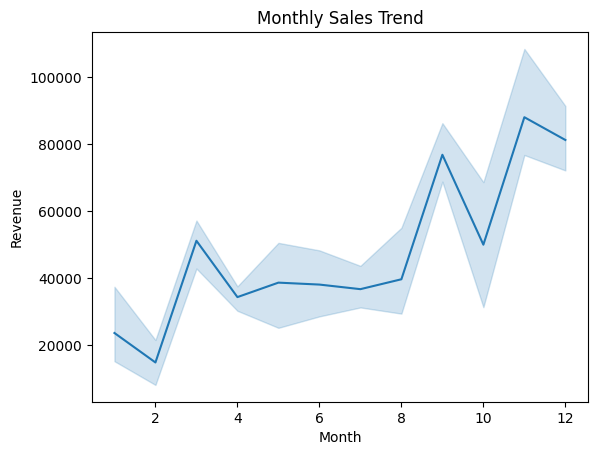

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.lineplot(data=monthly_sales, x='Month', y='Revenue')
plt.title('Monthly Sales Trend')
plt.show()

In [31]:
top_products = df.groupby('Sub-Category')['Revenue'].sum().sort_values(ascending=False)
top_products.head()

Sub-Category
Phones     330007.054
Chairs     328449.103
Storage    223843.608
Tables     206965.532
Binders    203412.733
Name: Revenue, dtype: float64

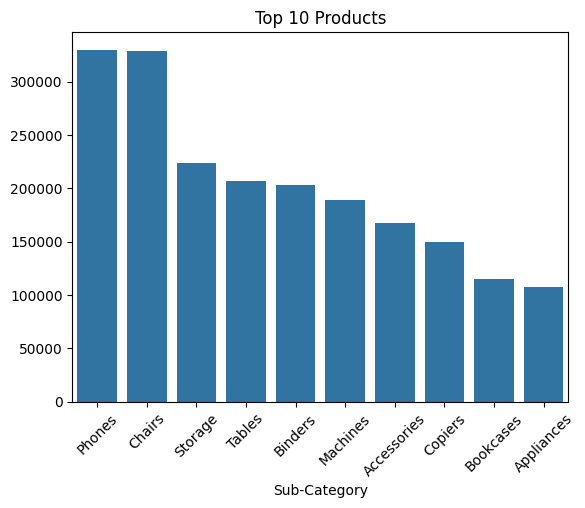

In [32]:
plt.figure()
sns.barplot(x=top_products.index[:10], y=top_products.values[:10])
plt.xticks(rotation=45)
plt.title('Top 10 Products')
plt.show()

In [33]:
region_sales = df.groupby('Region')['Revenue'].sum()
region_sales

Region
Central    501239.8908
East       678781.2400
South      391721.9050
West       725457.8245
Name: Revenue, dtype: float64

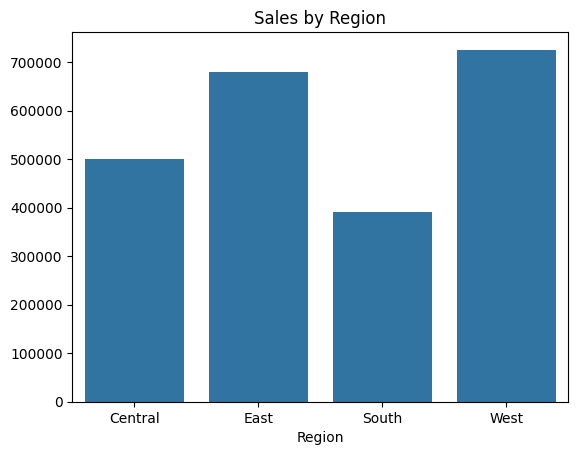

In [34]:
plt.figure()
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title('Sales by Region')
plt.show()

In [35]:
top_customers = df.groupby('Customer Name')['Revenue'].sum().sort_values(ascending=False)
top_customers.head()

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Revenue, dtype: float64

In [36]:
import sqlite3

conn = sqlite3.connect('sales.db')

df.to_sql('sales', conn, if_exists='replace', index=False)

9994

In [37]:
query = "SELECT SUM(Sales) as Total_Revenue FROM sales"
pd.read_sql(query, conn)

,Total_Revenue
0,2.297201e+06


In [38]:
query = """
SELECT "Sub-Category", SUM(Sales) as total_sales
FROM sales
GROUP BY "Sub-Category"
ORDER BY total_sales DESC
LIMIT 5
"""
pd.read_sql(query, conn)

,Sub-Category,total_sales
0,Phones,330007.054
1,Chairs,328449.103
2,Storage,223843.608
3,Tables,206965.532
4,Binders,203412.733


In [39]:
query = """
SELECT Year, Month, SUM(Sales) as total_sales
FROM sales
GROUP BY Year, Month
"""
pd.read_sql(query, conn)

,Year,Month,total_sales
0,2014,1,14236.8950
1,2014,2,4519.8920
2,2014,3,55691.0090
3,2014,4,28295.3450
4,2014,5,23648.2870
5,2014,6,34595.1276
6,2014,7,33946.3930
7,2014,8,27909.4685
8,2014,9,81777.3508
9,2014,10,31453.3930


In [40]:
query = """
SELECT Region, SUM(Sales) as total_sales
FROM sales
GROUP BY Region
"""
pd.read_sql(query, conn)

,Region,total_sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


In [41]:
query = """
SELECT "Customer Name", SUM(Sales) as total_sales
FROM sales
GROUP BY "Customer Name"
ORDER BY total_sales DESC
LIMIT 10
"""
pd.read_sql(query, conn)

,Customer Name,total_sales
0,Sean Miller,25043.050
1,Tamara Chand,19052.218
2,Raymond Buch,15117.339
3,Tom Ashbrook,14595.620
4,Adrian Barton,14473.571
5,Ken Lonsdale,14175.229
6,Sanjit Chand,14142.334
7,Hunter Lopez,12873.298
8,Sanjit Engle,12209.438
9,Christopher Conant,12129.072


In [42]:
query = """
SELECT Category, SUM(Profit) as total_profit
FROM sales
GROUP BY Category
"""
pd.read_sql(query, conn)

,Category,total_profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


In [43]:
query = "SELECT AVG(Sales) as avg_order_value FROM sales"
pd.read_sql(query, conn)

,avg_order_value
0,229.858001


Insight 1: Seasonal Sales Trend
Sales show noticeable variation across months, indicating seasonal demand patterns.
Certain months generate higher revenue, suggesting opportunities for targeted marketing and inventory planning.

Insight 2: Top Products Drive Majority Revenue
A small number of sub-categories contribute significantly to total sales.
This reflects the Pareto principle (80/20 rule) — focusing on top-performing products can maximize revenue.

Insight 3: Region-wise Performance Differences
Sales vary across regions, with some regions consistently outperforming others.
This suggests the need for region-specific strategies and promotions.

Insight 4: Customer Contribution is Uneven
A few customers contribute a large share of total revenue.
This highlights the importance of customer retention and loyalty programs.

Insight 5: High Sales ≠ High Profit
Some products generate high sales but low profit due to discounts or costs.
Businesses should focus on profitability, not just revenue.